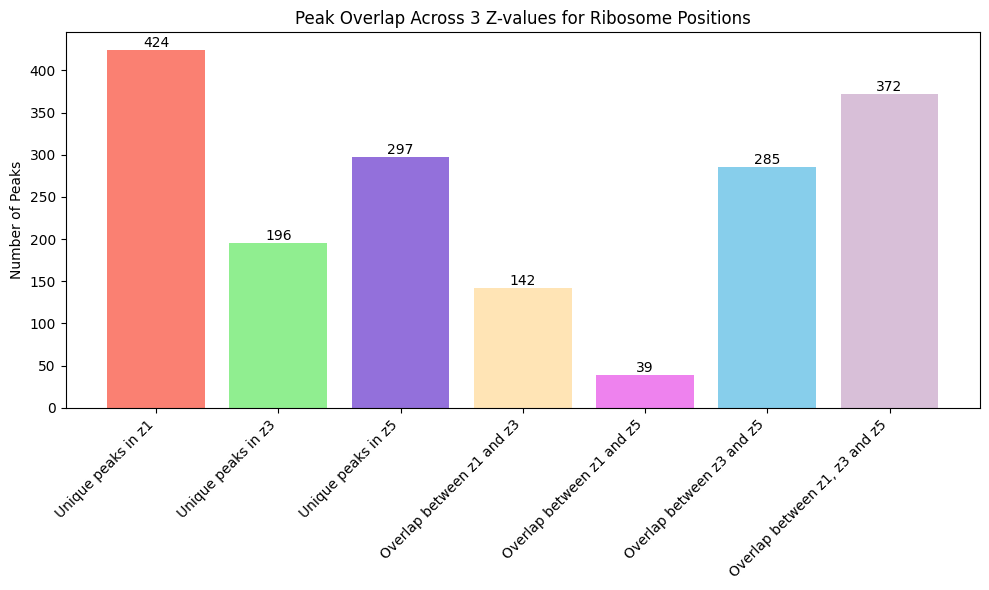

In [101]:
import pandas as pd
import matplotlib.pyplot as plt 

df = pd.read_csv("/scr/velara/bioinf2/TBI.Project.AG/results/results_bedtools/overlap_summary.bed", sep = "\t", header = None, names = ['transcript_id', 'start', 'end', 'num', 'files'])

counts = {
    "Unique peaks in z1": len(df[df['files'] == '1']),
    "Unique peaks in z3": len(df[df['files'] == '2']),
    "Unique peaks in z5": len(df[df['files'] == '3']),
    "Overlap between z1 and z3": len(df[df['files'] == '1,2']),
    "Overlap between z1 and z5": len(df[df['files'] == '1,3']),
    "Overlap between z3 and z5": len(df[df['files'] == '2,3']),
    "Overlap between z1, z3 and z5": len(df[df['files'] == '1,2,3'])
}

plot_df = pd.DataFrame(list(counts.items()), columns = ['Category', 'Count'])

plt.figure(figsize=(10,6))
bars = plt.bar(plot_df['Category'], plot_df['Count'], color= ['salmon', 'lightgreen', 'mediumpurple', 'moccasin', 'violet', 'skyblue', 'thistle'])

for bar  in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Peaks")
plt.title("Peak Overlap Across 3 Z-values for Ribosome Positions")
plt.tight_layout()
plt.show()

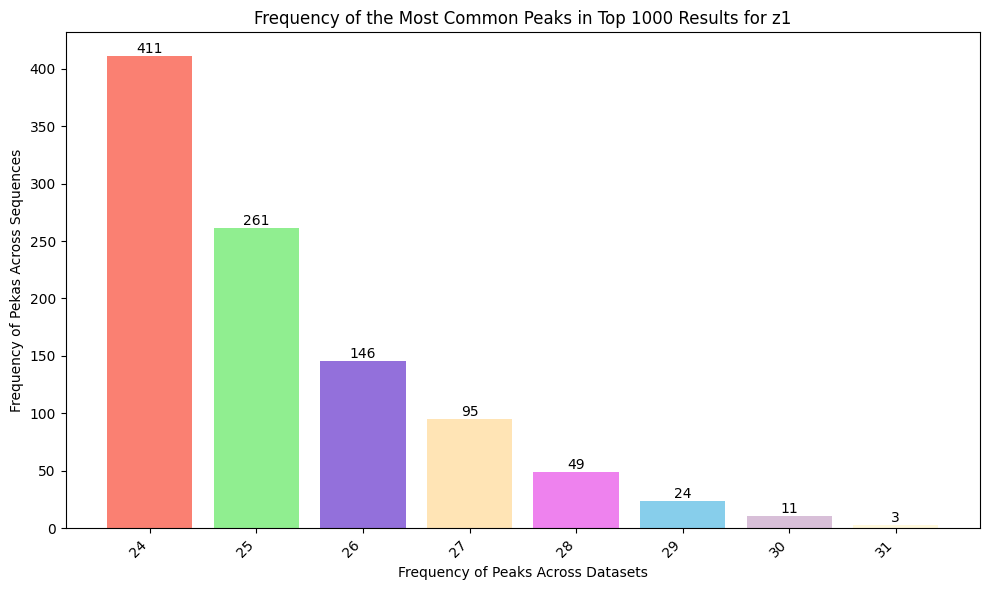

In [103]:
df = pd.read_csv("/scr/velara/bioinf2/TBI.Project.AG/visual_data/input_data/z1_top_1000.tsv", sep = "\t", header = 0, names = ['transcript_id', 'peak_position', 'count', 'data_sets'])

df['count'] = df['count'].astype(int)

counts = df['count'].value_counts().sort_index()

plt.figure(figsize=(10,6))
bars = plt.bar(counts.index, counts.values, color= ['salmon', 'lightgreen', 'mediumpurple', 'moccasin', 'violet', 'skyblue', 'thistle', 'cornsilk'])

for bar  in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency of Pekas Across Sequences")
plt.xlabel("Frequency of Peaks Across Datasets")
plt.title("Frequency of the Most Common Peaks in Top 1000 Results for z1")
plt.xticks(counts.index)
plt.tight_layout()
plt.show()


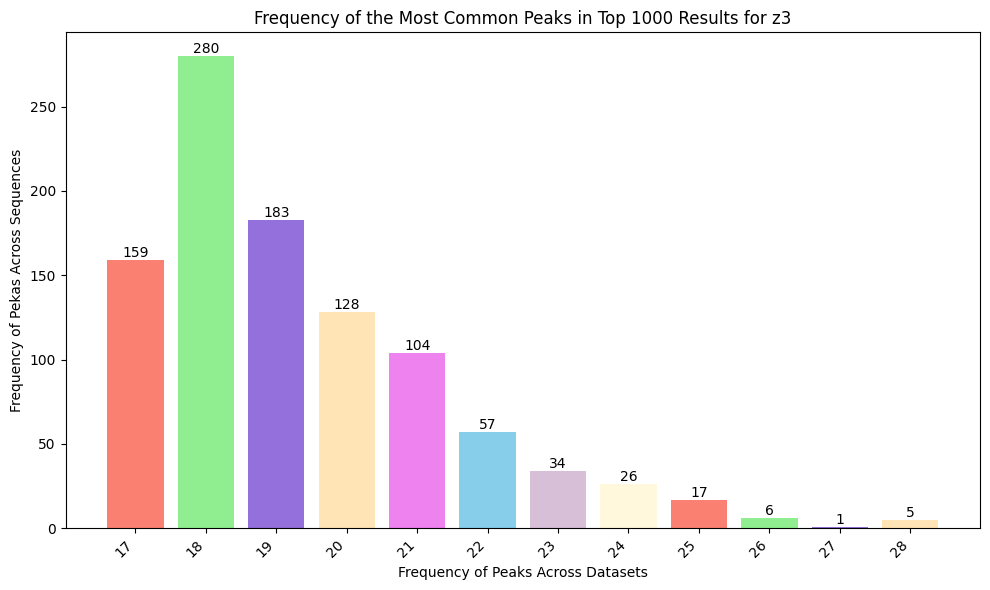

In [104]:
df = pd.read_csv("/scr/velara/bioinf2/TBI.Project.AG/visual_data/input_data/z3_top_1000.tsv", sep = "\t", header = 0, names = ['transcript_id', 'peak_position', 'count', 'data_sets'])

df['count'] = df['count'].astype(int)

counts = df['count'].value_counts().sort_index()

plt.figure(figsize=(10,6))
bars = plt.bar(counts.index, counts.values, color= ['salmon', 'lightgreen', 'mediumpurple', 'moccasin', 'violet', 'skyblue', 'thistle', 'cornsilk'])

for bar  in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency of Pekas Across Sequences")
plt.xlabel("Frequency of Peaks Across Datasets")
plt.title("Frequency of the Most Common Peaks in Top 1000 Results for z3")
plt.xticks(counts.index)
plt.tight_layout()
plt.show()


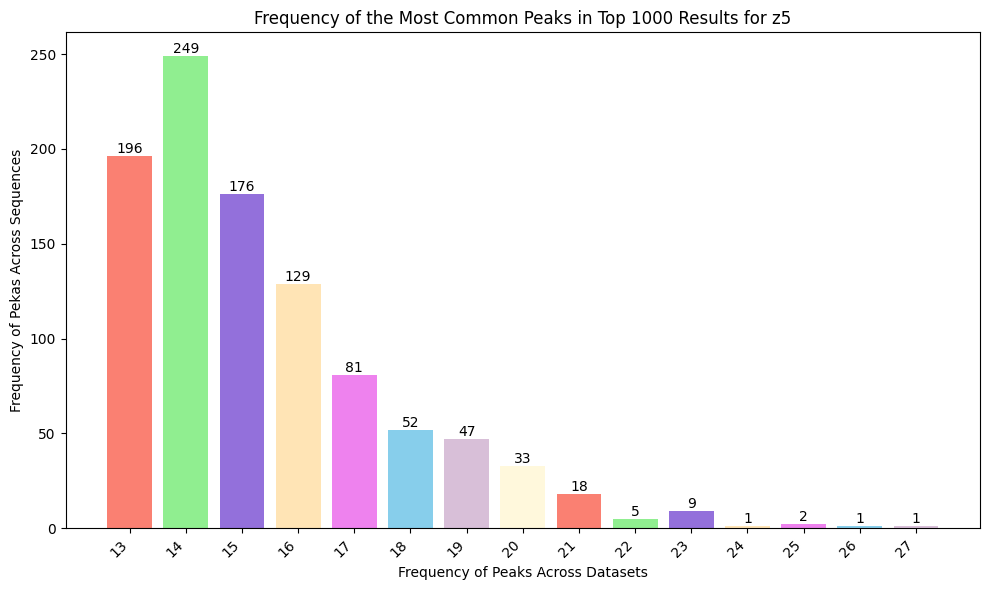

In [105]:
df = pd.read_csv("/scr/velara/bioinf2/TBI.Project.AG/visual_data/input_data/z5_top_1000.tsv", sep = "\t", header = 0, names = ['transcript_id', 'peak_position', 'count', 'data_sets'])

df['count'] = df['count'].astype(int)

counts = df['count'].value_counts().sort_index()

plt.figure(figsize=(10,6))
bars = plt.bar(counts.index, counts.values, color= ['salmon', 'lightgreen', 'mediumpurple', 'moccasin', 'violet', 'skyblue', 'thistle', 'cornsilk'])

for bar  in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency of Pekas Across Sequences")
plt.xlabel("Frequency of Peaks Across Datasets")
plt.title("Frequency of the Most Common Peaks in Top 1000 Results for z5")
plt.xticks(counts.index)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as nump
import os
import pandas as pd
import matplotlib.pyplot as plt

input_data = 'data'
output_data = 'output'

if not os.path.exists(input_data):
    os.mkdir(input_data)
if not os.path.exists(output_data):
    os.mkdir(output_data)

files = [
    'visual_data/input_data/z1_top_1000.tsv',
    'visual_data/input_data/z3_top_1000.tsv',
    'visual_data/input_data/z5_top_1000.tsv'
]

dataframe_list = []

for f in files:
    df = pd.read_csv(f, sep="\t", header=None, names=['transcript_id', 'peak_position', 'count', 'data_sets'])
    dataframe_list.append(df)

merged_df = pd.concat(dataframe_list)

counts = merged_df.groupby(['count', 'transcript_id'])
counts_df = counts.unstack()

'''
plt.figure(figsize=(10,6))
plt.bar(counts.index, counts.values, color=['salmon', 'lightgreen', 'mediumpurple', 'moccasin', 'violet', 'skyblue', 'thistle', 'cornsilk'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency of Pekas Across Sequences")
plt.xlabel("Frequency of Peaks Across Datasets")
plt.title("Frequency of the Most Common Peaks in Top 1000 Results for z5")
plt.xticks(counts.index)
plt.tight_layout()
plt.show()
'''

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(20, 10)
counts.plot(kind='bar', ax=ax, colormap='tab20')
ax.set_ylabel('Frequency of Peaks Across Datasets', size=15)
ax.set_xlabel('Peak Count', size=15)
ax.set_title('Frequency of the Most Common Peaks in Top 1000 Results across all z-values', size=18, y=1.1)
plt.show()


AttributeError: 'DataFrameGroupBy' object has no attribute 'unstack'

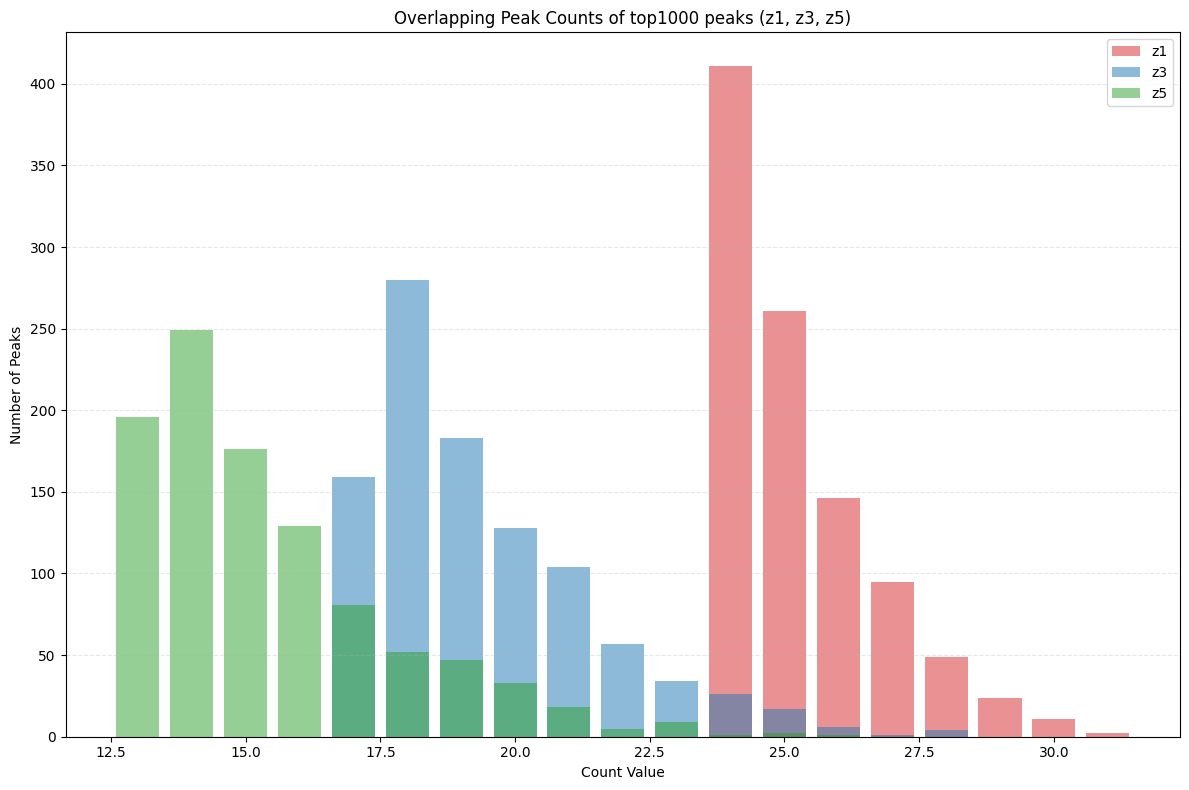

In [118]:
files = [
    'visual_data/input_data/z1_top_1000.tsv',
    'visual_data/input_data/z3_top_1000.tsv',
    'visual_data/input_data/z5_top_1000.tsv'
]

labels = ['z1', 'z3', 'z5']
colors = ['tab:red', 'tab:blue', 'tab:green']

fig, ax = plt.subplots(figsize=(12, 8))

for file_path, label_name, color_code in zip(files, labels, colors):
    
    df = pd.read_csv(file_path, header = 1, sep="\t", names=['transcript_id', 'peak_position', 'count', 'data_sets'])

    frequencies = df['count'].value_counts()

    ax.bar(frequencies.index, 
           frequencies.values, 
           label=label_name, 
           color=color_code, 
           alpha=0.5,
           width=0.8)

ax.set_ylabel('Number of Peaks')
ax.set_xlabel('Count Value')
ax.set_title('Overlapping Peak Counts of top1000 peaks (z1, z3, z5)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

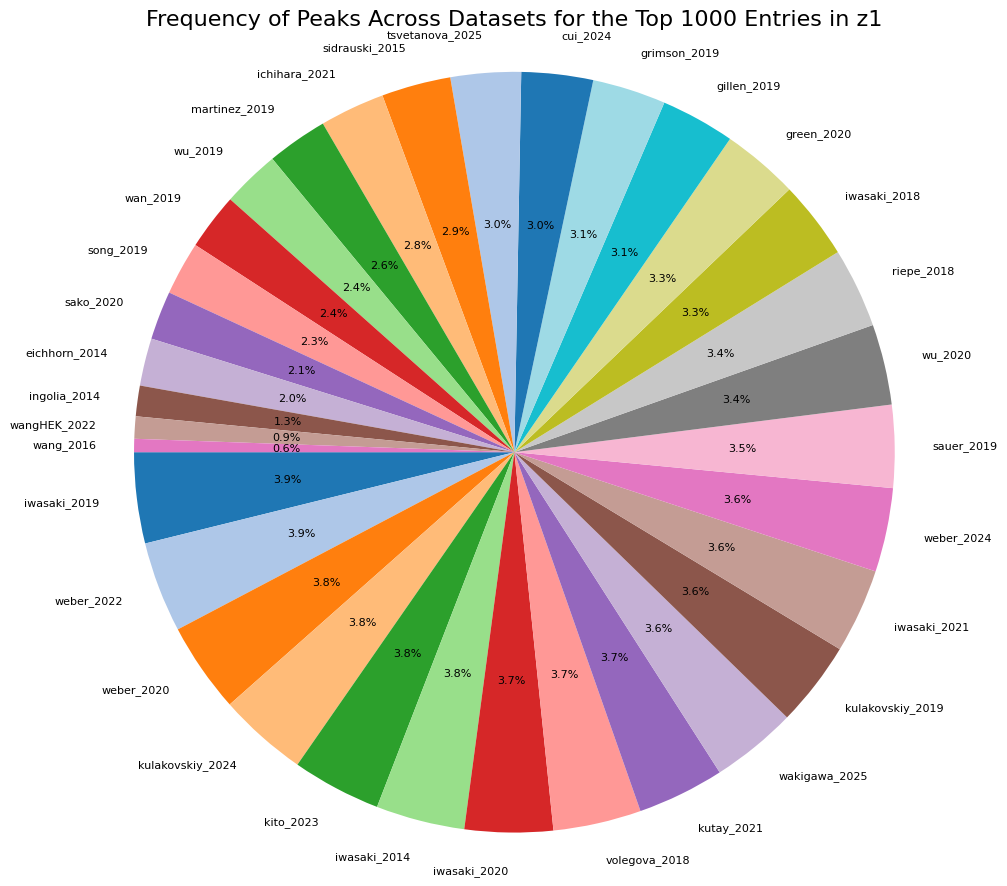

In [74]:
from collections import Counter

df = pd.read_csv("/scr/velara/bioinf2/TBI.Project.AG/results/results_bedtools/z1_top_1000.tsv", sep = "\t", header = 0, names = ['transcript_id', 'peak_position', 'count', 'data_sets'])

dataset_counts = df['data_sets'].value_counts()
all_datasets = df['data_sets'].dropna().str.split(',')

flat_list = [item.strip() for sublist in all_datasets for item in sublist]
dataset_counter = Counter(flat_list)
dataset_counts = pd.Series(dataset_counter).sort_values(ascending=False)

plt.figure(figsize=(10,10))
plt.pie(dataset_counts, labels=dataset_counts.index, autopct='%1.1f%%', startangle=180, colors=plt.cm.tab20.colors, textprops={'fontsize': 8})
plt.title("Frequency of Peaks Across Datasets for the Top 1000 Entries in z1", fontsize = 16)
plt.tight_layout(pad=5)
plt.axis('equal') 
plt.show()

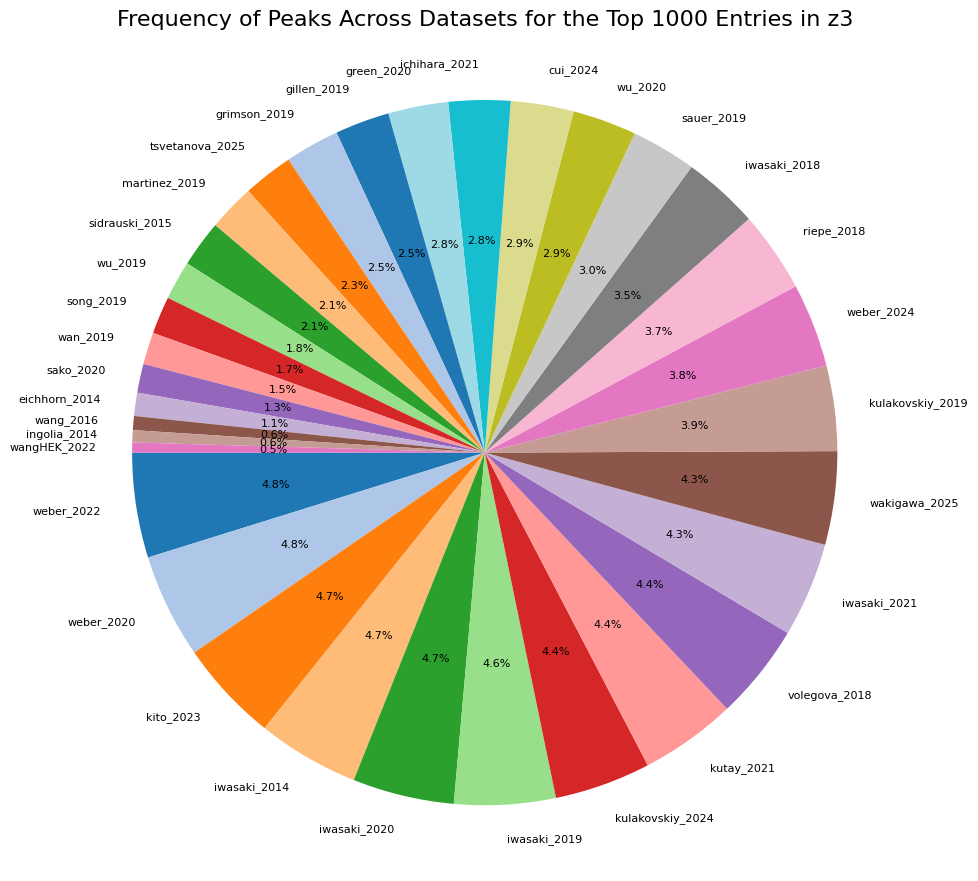

In [77]:
from collections import Counter

df = pd.read_csv("/scr/velara/bioinf2/TBI.Project.AG/results/results_bedtools/z3_top_1000.tsv", sep = "\t", header = 0, names = ['transcript_id', 'peak_position', 'count', 'data_sets'])

dataset_counts = df['data_sets'].value_counts()
all_datasets = df['data_sets'].dropna().str.split(',')

flat_list = [item.strip() for sublist in all_datasets for item in sublist]
dataset_counter = Counter(flat_list)
dataset_counts = pd.Series(dataset_counter).sort_values(ascending=False)

plt.figure(figsize=(10,10))
plt.pie(dataset_counts, labels=dataset_counts.index, autopct='%1.1f%%', startangle=180, colors=plt.cm.tab20.colors, textprops={'fontsize': 8})
plt.title("Frequency of Peaks Across Datasets for the Top 1000 Entries in z3", fontsize = 16)
plt.tight_layout(pad=5)
plt.axis('equal') 
plt.show()

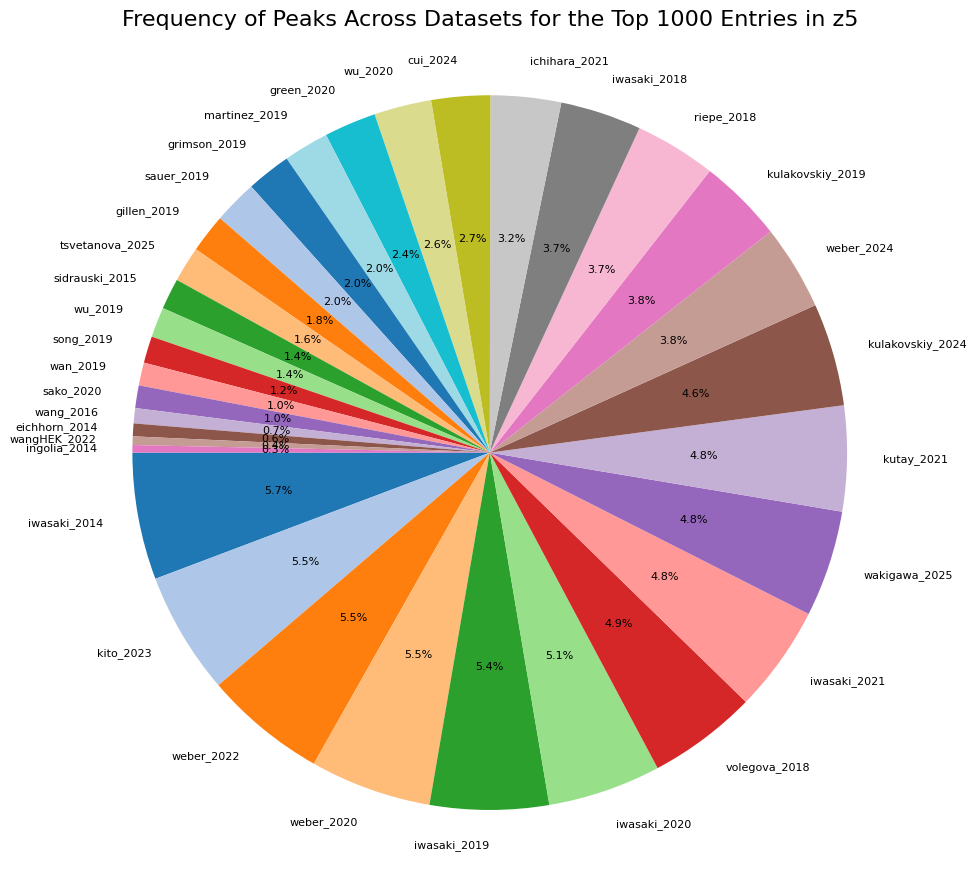

In [76]:
from collections import Counter

df = pd.read_csv("/scr/velara/bioinf2/TBI.Project.AG/results/results_bedtools/z5_top_1000.tsv", sep = "\t", header = 0, names = ['transcript_id', 'peak_position', 'count', 'data_sets'])

dataset_counts = df['data_sets'].value_counts()
all_datasets = df['data_sets'].dropna().str.split(',')

flat_list = [item.strip() for sublist in all_datasets for item in sublist]
dataset_counter = Counter(flat_list)
dataset_counts = pd.Series(dataset_counter).sort_values(ascending=False)

plt.figure(figsize=(10,10))
plt.pie(dataset_counts, labels=dataset_counts.index, autopct='%1.1f%%', startangle=180, colors=plt.cm.tab20.colors, textprops={'fontsize': 8})
plt.title("Frequency of Peaks Across Datasets for the Top 1000 Entries in z5", fontsize = 16)
plt.tight_layout(pad=5)
plt.axis('equal') 
plt.show()

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_venn         
df = pd.read_csv("/scr/velara/bioinf2/TBI.Project.AG/results/results_bedtools/overlap_summary.bed", sep = "\t", header = None, names = ['transcript_id', 'start', 'end', 'num', 'files'])

counts = {
    "100": len(df[df['files'] == '1']),
    "010": len(df[df['files'] == '2']),
    "001": len(df[df['files'] == '3']),
    "110": len(df[df['files'] == '1,2']),
    "101": len(df[df['files'] == '1,3']),
    "011": len(df[df['files'] == '2,3']),
    "111": len(df[df['files'] == '1,2,3'])
}

plt.figure(figsize=(8,8))
matplotlib_venn.venn3(subsets=counts, set_labels=('z1','z3','z5'))
plt.title("Peak Overlaps Across z1, z3, z5")
#plt.savefig("venn_diagram.png")
print("Venn diagram saved as venn_diagram.png")


: 